# 03 — Clasificación PROGRAMADA vs IMPREVISTA (Panel 2)

**Entrada**: `data/processed/interrupciones_enriquecido.csv`.
**Salidas**: tablas de métricas en `data/processed/` y el modelo ganador
serializado en `dashboard/modelos/` (insumos del Panel 2 del dashboard).

Obligaciones del Panel 2: **≥5 algoritmos comparados** (aquí 6), métricas
accuracy / precisión / recall / F1 por clase / ROC-AUC, **matriz de confusión**
interpretada, manejo del **desbalance 76/24** mostrando el efecto en el recall de
la clase minoritaria, análisis de **leakage** de `motivo_agrupado`, y
**SHAP + LIME** sobre el modelo ganador.

In [1]:
RANDOM_STATE = 42
TEST_SIZE = 0.30        # el profesor puede pedir 0.10
N_ESTIMATORS = 100      # el profesor puede pedir 500
LEARNING_RATE = 0.1     # el profesor puede pedir 0.01
N_VECINOS_KNN = 15
SHAP_MUESTRA = 2000     # filas del test usadas para el summary plot

In [2]:
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from imblearn.over_sampling import SMOTE
from lime.lime_tabular import LimeTabularExplainer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

RAIZ = Path.cwd() if (Path.cwd() / "data" / "processed").exists() else Path.cwd().parent
RUTA_PROCESSED = RAIZ / "data" / "processed"

df = pd.read_csv(RUTA_PROCESSED / "interrupciones_enriquecido.csv")
print("enriquecido:", df.shape)

enriquecido: (44043, 25)


## 1. Definición del problema y selección de features

**Target**: `y = 1` si el corte es **PROGRAMADA** (clase minoritaria, 23.9%) y
`y = 0` si es IMPREVISTA. Se elige la minoritaria como clase positiva porque el
manejo del desbalance se evalúa sobre su recall.

**Escenario operativo**: predecir el tipo con la información disponible **cuando el
corte se reporta**. Por eso se excluyen:

- `duracion_horas` y `fecha_fin` — solo se conocen cuando el corte terminó (leakage temporal).
- `anio` — un modelo que aprende "2021" no generaliza a años futuros.
- `DISTRITO` / `PROVINCIA` — 300+/150+ categorías; se usa `DEPARTAMENTO` (25) +
  `poblacion_distrito` como representación geográfica compacta.
- `EPS` — 48 categorías casi colineales con el departamento.
- `MOTIVOINTERRUPCION` crudo — se usa `motivo_agrupado` (11 categorías), cuyo
  posible leakage semántico se analiza en la sección 5.

In [3]:
COLS_NUMERICAS = ["mes", "dia_semana_num", "es_fin_de_semana", "es_feriado",
                  "hora_inicio_num", "NUMCONEXDOM", "UNIDADESUSO",
                  "NUMCAMIONESPUNTOS", "reporta_conexiones", "ratio_afectados",
                  "poblacion_distrito"]
COLS_CATEGORICAS = ["motivo_agrupado", "DEPARTAMENTO", "hora_inicio_bin"]

X = pd.get_dummies(df[COLS_NUMERICAS + COLS_CATEGORICAS],
                   columns=COLS_CATEGORICAS, dtype=int).astype(float)
y = (df["TIPOINTERRUPCION"] == "PROGRAMADA").astype(int)

print("X:", X.shape, "| positivos (PROGRAMADA):", int(y.sum()),
      f"({y.mean() * 100:.1f}%)")

X: (44043, 51) | positivos (PROGRAMADA): 10523 (23.9%)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

# 50.5% de nulos en NUMCONEXDOM/UNIDADESUSO (y ratio_afectados derivado):
# se imputa con la MEDIANA calculada SOLO sobre train (evita contaminar el test);
# el flag reporta_conexiones conserva la marca de "dato imputado" para el modelo.
medianas = X_train.median()
X_train = X_train.fillna(medianas)
X_test = X_test.fillna(medianas)

# Escalado solo para los modelos basados en distancia/gradiente
# (los árboles no lo necesitan: pregunta típica del profesor)
escalador = StandardScaler().fit(X_train)
X_train_esc = pd.DataFrame(escalador.transform(X_train), columns=X.columns, index=X_train.index)
X_test_esc = pd.DataFrame(escalador.transform(X_test), columns=X.columns, index=X_test.index)

print("train:", X_train.shape, "| test:", X_test.shape)

train: (30830, 51) | test: (13213, 51)


## 2. Comparativa de 6 algoritmos

Se aplica `class_weight='balanced'` (o `scale_pos_weight` en XGBoost) en los
modelos que lo soportan; KNN, Naive Bayes y MLP no lo tienen — la alternativa
universal (SMOTE) se evalúa en la sección 4.

In [5]:
peso_positivo = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"scale_pos_weight = {peso_positivo:.2f}")

# (modelo, usa_escalado)
MODELOS = {
    "Regresion Logistica": (LogisticRegression(max_iter=2000, class_weight="balanced",
                                               random_state=RANDOM_STATE), True),
    "KNN": (KNeighborsClassifier(n_neighbors=N_VECINOS_KNN), True),
    "Naive Bayes": (GaussianNB(), False),
    "Random Forest": (RandomForestClassifier(n_estimators=N_ESTIMATORS,
                                             class_weight="balanced",
                                             random_state=RANDOM_STATE, n_jobs=-1), False),
    "XGBoost": (XGBClassifier(n_estimators=N_ESTIMATORS, learning_rate=LEARNING_RATE,
                              scale_pos_weight=peso_positivo, eval_metric="logloss",
                              random_state=RANDOM_STATE, n_jobs=-1), False),
    "MLP": (MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
                          random_state=RANDOM_STATE), True),
}


def evaluar(modelo, X_tr, y_tr, X_te):
    """Entrena y devuelve las métricas obligatorias del Panel 2 sobre el test."""
    t0 = time.perf_counter()
    modelo.fit(X_tr, y_tr)
    segundos = time.perf_counter() - t0
    pred = modelo.predict(X_te)
    proba = modelo.predict_proba(X_te)[:, 1]
    return {
        "accuracy": accuracy_score(y_test, pred),
        "prec_PROG": precision_score(y_test, pred, pos_label=1),
        "rec_PROG": recall_score(y_test, pred, pos_label=1),
        "f1_PROG": f1_score(y_test, pred, pos_label=1),
        "prec_IMPREV": precision_score(y_test, pred, pos_label=0),
        "rec_IMPREV": recall_score(y_test, pred, pos_label=0),
        "f1_IMPREV": f1_score(y_test, pred, pos_label=0),
        "roc_auc": roc_auc_score(y_test, proba),
        "seg_entren": segundos,
    }

scale_pos_weight = 3.19


In [6]:
filas = []
for nombre, (modelo, usa_escalado) in MODELOS.items():
    X_tr = X_train_esc if usa_escalado else X_train
    X_te = X_test_esc if usa_escalado else X_test
    filas.append({"modelo": nombre} | evaluar(modelo, X_tr, y_train, X_te))
    print(f"listo: {nombre}")

comparativa = (pd.DataFrame(filas).set_index("modelo")
               .sort_values("f1_PROG", ascending=False))
comparativa.round(3)

listo: Regresion Logistica


listo: KNN
listo: Naive Bayes


listo: Random Forest


listo: XGBoost


listo: MLP


,accuracy,prec_PROG,rec_PROG,f1_PROG,prec_IMPREV,rec_IMPREV,f1_IMPREV,roc_auc,seg_entren
modelo,,,,,,,,,
Random Forest,0.958,0.906,0.918,0.912,0.974,0.970,0.972,0.986,0.401
XGBoost,0.945,0.854,0.929,0.890,0.977,0.950,0.963,0.984,0.351
MLP,0.947,0.923,0.850,0.885,0.954,0.978,0.966,0.981,1.675
KNN,0.942,0.906,0.846,0.875,0.953,0.972,0.962,0.977,0.008
Regresion Logistica,0.920,0.794,0.896,0.842,0.966,0.927,0.946,0.974,0.068
Naive Bayes,0.258,0.241,0.978,0.386,0.818,0.032,0.061,0.588,0.028


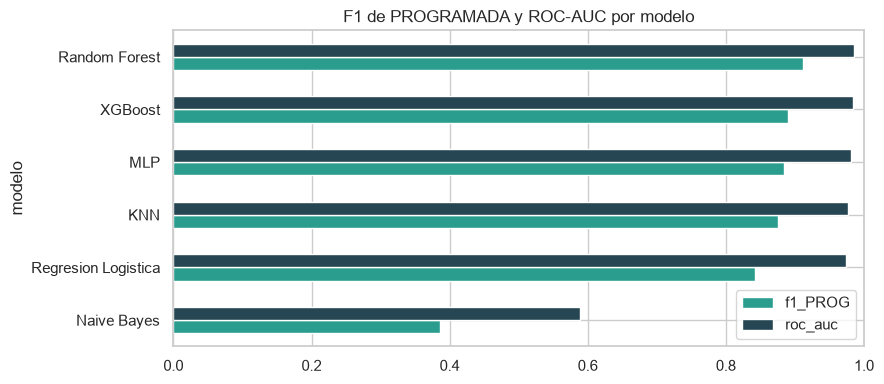

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
comparativa[["f1_PROG", "roc_auc"]].sort_values("f1_PROG").plot(
    kind="barh", ax=ax, color=["#2a9d8f", "#264653"])
ax.set_title("F1 de PROGRAMADA y ROC-AUC por modelo")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

**Modelo ganador: Random Forest** — se elige por **F1 de la clase minoritaria**
(no por accuracy, que con 76/24 premia al que ignora PROGRAMADA) con ROC-AUC como
desempate: RF logra F1_PROG **0.912** y ROC-AUC **0.986**, por encima de XGBoost
(0.890 / 0.984) y MLP (0.885 / 0.981). Además no requiere escalado y captura
no-linealidades e interacciones sin ingeniería extra (respuesta a la pregunta
típica "¿por qué RF sobre regresión logística?": la logística queda en 0.842).
**Naive Bayes colapsa** (F1 0.386): su supuesto de gaussianas independientes por
feature es absurdo con ~40 dummies binarias — predice PROGRAMADA casi siempre
(recall 0.98, precisión 0.24). Buen ejemplo de por qué se comparan familias.

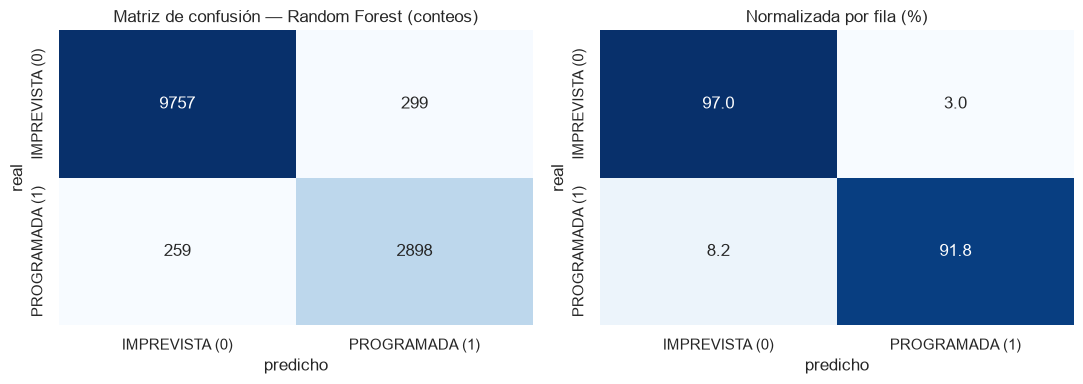

In [8]:
NOMBRE_GANADOR = "Random Forest"    # según la tabla comparativa
ganador = MODELOS[NOMBRE_GANADOR][0]  # ya entrenado en el loop
pred_ganador = pd.Series(ganador.predict(X_test), index=X_test.index)
proba_ganador = pd.Series(ganador.predict_proba(X_test)[:, 1], index=X_test.index)

cm = confusion_matrix(y_test, pred_ganador, labels=[0, 1])
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
etiquetas_clase = ["IMPREVISTA (0)", "PROGRAMADA (1)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=etiquetas_clase, yticklabels=etiquetas_clase, ax=axes[0])
axes[0].set_title(f"Matriz de confusión — {NOMBRE_GANADOR} (conteos)")
axes[0].set_ylabel("real")
axes[0].set_xlabel("predicho")
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues", cbar=False,
            xticklabels=etiquetas_clase, yticklabels=etiquetas_clase, ax=axes[1])
axes[1].set_title("Normalizada por fila (%)")
axes[1].set_ylabel("real")
axes[1].set_xlabel("predicho")
plt.tight_layout()
plt.show()

**¿Qué error es más costoso?** Un corte **IMPREVISTA clasificado como PROGRAMADA**
(celda superior derecha: real=IMPREVISTA, predicho=PROGRAMADA) implica tratar una
emergencia como si estuviera planificada: no se activan cisternas ni comunicación
de contingencia. El error inverso (PROGRAMADA→IMPREVISTA, celda inferior izquierda)
solo genera una alerta de más. Por eso, además del F1, vigilamos la **precisión de
PROGRAMADA**: cuando el modelo dice "programada", debe estar seguro.

## 4. Desbalance 76/24: efecto de cada técnica en el recall de PROGRAMADA

Exigencia del profesor: aplicar `class_weight`/SMOTE y **mostrar el efecto en el
recall de la clase minoritaria**. Se compara el ganador (Random Forest) en 3
configuraciones: sin ajuste, con `class_weight='balanced'` y con SMOTE
(sobre-muestreo sintético **solo sobre train** — aplicarlo al test inflaría las
métricas).

In [9]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("train tras SMOTE:", X_train_sm.shape,
      f"| % PROGRAMADA: {y_train_sm.mean() * 100:.1f}%")


def rf_base(**extra):
    return RandomForestClassifier(n_estimators=N_ESTIMATORS,
                                  random_state=RANDOM_STATE, n_jobs=-1, **extra)


filas_desb = [
    {"configuracion": "RF sin ajuste"} | evaluar(rf_base(), X_train, y_train, X_test),
    {"configuracion": "RF class_weight=balanced"} | evaluar(rf_base(class_weight="balanced"),
                                                            X_train, y_train, X_test),
    {"configuracion": "RF + SMOTE"} | evaluar(rf_base(), X_train_sm, y_train_sm, X_test),
]
tabla_desbalance = pd.DataFrame(filas_desb).set_index("configuracion")[
    ["rec_PROG", "prec_PROG", "f1_PROG", "roc_auc", "accuracy"]]
tabla_desbalance.round(3)

train tras SMOTE: (46928, 51) | % PROGRAMADA: 50.0%


,rec_PROG,prec_PROG,f1_PROG,roc_auc,accuracy
configuracion,,,,,
RF sin ajuste,0.885,0.939,0.911,0.985,0.959
RF class_weight=balanced,0.918,0.906,0.912,0.986,0.958
RF + SMOTE,0.887,0.934,0.910,0.986,0.958


**Efecto sobre el recall de la clase minoritaria** (exigencia del profesor):
`class_weight='balanced'` sube el recall de PROGRAMADA de **0.885 a 0.918**
(+3.3 pts) cediendo ~3.2 pts de precisión (0.939 → 0.907), con F1 estable
(0.911 → 0.912). SMOTE queda a medio camino (recall 0.887). Con un desbalance
moderado (76/24) el efecto es acotado pero visible; con desbalances >90/10 la
diferencia sería dramática. **Configuración elegida**: `class_weight='balanced'`
— mejor recall de la minoritaria a igual F1 y sin el costo de generar ~16K filas
sintéticas en cada reentrenamiento.

## 5. Análisis de leakage: ¿`motivo_agrupado` regala el target?

El EDA (notebook 02) mostró motivos casi deterministas ("ROTURA" ⇒ imprevista,
"MANTENIMIENTO" ⇒ programada). El motivo **sí se conoce al reportarse el corte**
(no es leakage temporal), pero puede reducir el modelo a una tabla de búsqueda.
Prueba: reentrenar el ganador **sin** las dummies de motivo.

In [10]:
cols_motivo = [c for c in X.columns if c.startswith("motivo_agrupado_")]
X_train_sin = X_train.drop(columns=cols_motivo)
X_test_sin = X_test.drop(columns=cols_motivo)

filas_leak = [
    {"features": "con motivo_agrupado"} | evaluar(rf_base(class_weight="balanced"),
                                                  X_train, y_train, X_test),
    {"features": "sin motivo_agrupado"} | evaluar(rf_base(class_weight="balanced"),
                                                  X_train_sin, y_train, X_test_sin),
]
tabla_leakage = pd.DataFrame(filas_leak).set_index("features")[
    ["f1_PROG", "rec_PROG", "prec_PROG", "roc_auc", "accuracy"]]
tabla_leakage.round(3)

,f1_PROG,rec_PROG,prec_PROG,roc_auc,accuracy
features,,,,,
con motivo_agrupado,0.912,0.918,0.906,0.986,0.958
sin motivo_agrupado,0.752,0.800,0.710,0.923,0.874


**Decisión** (se documenta en el informe): sin `motivo_agrupado` el F1 de
PROGRAMADA cae de **0.912 a 0.753** (−16 pts) pero el ROC-AUC se mantiene en
**0.923**: el motivo aporta mucho, pero el modelo NO es una tabla de búsqueda —
hora, calendario, geografía y conexiones sostienen por sí solas un clasificador
útil. `motivo_agrupado` se **mantiene** porque es información legítimamente
disponible cuando la EPS reporta el corte (no hay leakage temporal), y el ablation
queda como evidencia de robustez ante la pregunta del profesor.

## 6. Interpretabilidad: SHAP (global + 1 caso) y LIME (obligatorio)

shap values: (2000, 51) | valor base (prob. media PROGRAMADA): 0.5


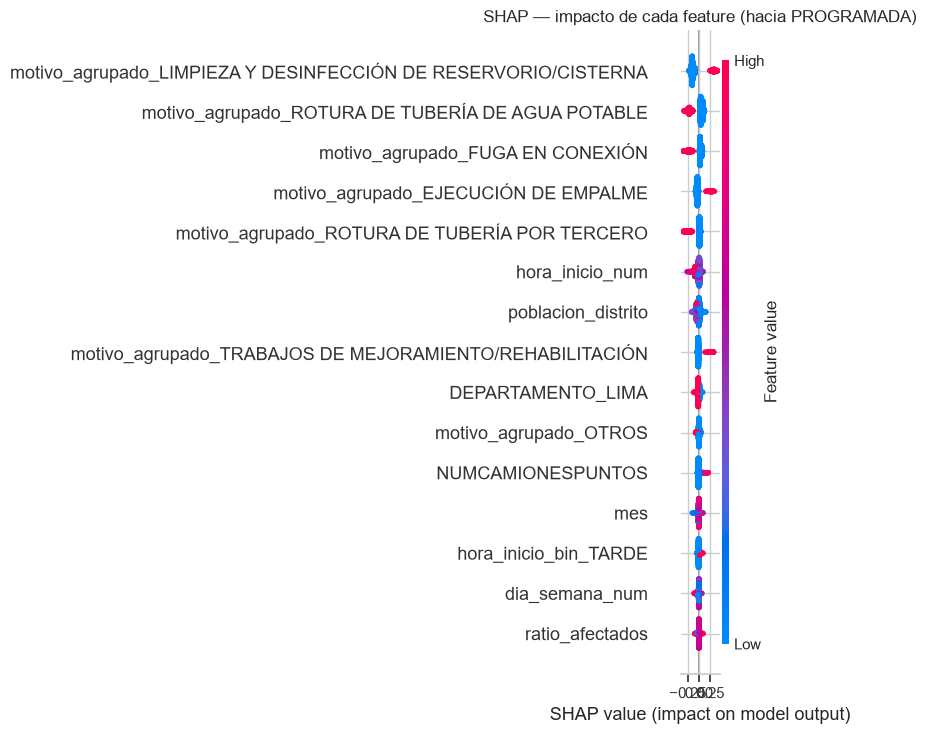

In [11]:
# Los gráficos SHAP/LIME se guardan como PNG: el Panel 2 del dashboard los embebe
# tal cual (recalcular SHAP en cada arranque de Streamlit Cloud sería muy lento).
RUTA_RECURSOS = RAIZ / "dashboard" / "recursos"
RUTA_RECURSOS.mkdir(parents=True, exist_ok=True)

explicador = shap.TreeExplainer(ganador)
X_muestra = X_test.sample(n=min(SHAP_MUESTRA, len(X_test)), random_state=RANDOM_STATE)
valores_shap = explicador.shap_values(X_muestra)

# Random Forest binario devuelve un valor SHAP por clase:
# nos quedamos con los de la clase PROGRAMADA (1)
if isinstance(valores_shap, list):
    shap_prog = valores_shap[1]
elif np.ndim(valores_shap) == 3:
    shap_prog = valores_shap[:, :, 1]
else:
    shap_prog = valores_shap
valor_base = float(np.atleast_1d(explicador.expected_value)[-1])
print("shap values:", np.shape(shap_prog), "| valor base (prob. media PROGRAMADA):",
      round(valor_base, 3))

shap.summary_plot(shap_prog, X_muestra, max_display=15, show=False)
plt.title("SHAP — impacto de cada feature (hacia PROGRAMADA)")
plt.tight_layout()
plt.savefig(RUTA_RECURSOS / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

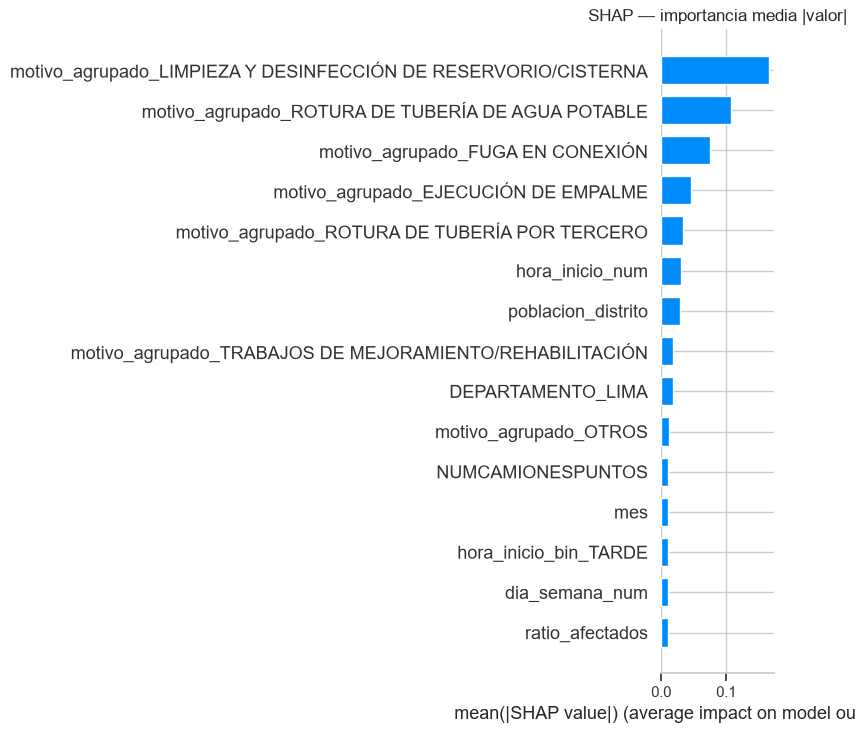

In [12]:
shap.summary_plot(shap_prog, X_muestra, plot_type="bar", max_display=15, show=False)
plt.title("SHAP — importancia media |valor|")
plt.tight_layout()
plt.savefig(RUTA_RECURSOS / "shap_importancia.png", dpi=150, bbox_inches="tight")
plt.show()

caso elegido (fila original):
EPS                                                        SEDAPAL
DEPARTAMENTO                                                  LIMA
DISTRITO                                    SAN JUAN DE LURIGANCHO
motivo_agrupado     LIMPIEZA Y DESINFECCIÓN DE RESERVORIO/CISTERNA
hora_inicio_bin                                             MANANA
NUMCONEXDOM                                                 2014.0
TIPOINTERRUPCION                                        PROGRAMADA
Name: 6000, dtype: object
probabilidad de PROGRAMADA segun el modelo: 1.000


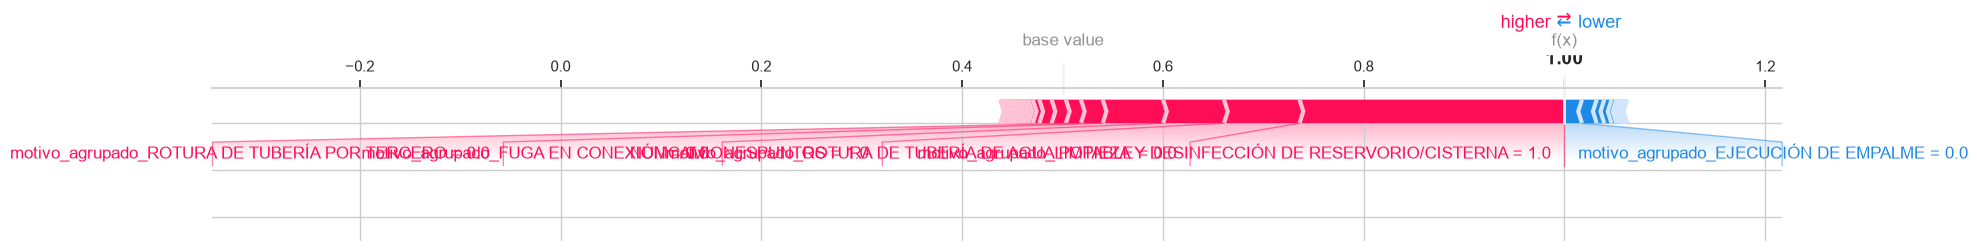

In [13]:
# caso: una PROGRAMADA correctamente detectada en el test
idx_caso = X_test.index[(y_test == 1) & (pred_ganador == 1)][0]
print("caso elegido (fila original):")
print(df.loc[idx_caso, ["EPS", "DEPARTAMENTO", "DISTRITO", "motivo_agrupado",
                        "hora_inicio_bin", "NUMCONEXDOM", "TIPOINTERRUPCION"]])
print(f"probabilidad de PROGRAMADA segun el modelo: {proba_ganador.loc[idx_caso]:.3f}")

shap_caso = explicador.shap_values(X_test.loc[[idx_caso]])
if isinstance(shap_caso, list):
    shap_caso_prog = shap_caso[1]
elif np.ndim(shap_caso) == 3:
    shap_caso_prog = shap_caso[:, :, 1]
else:
    shap_caso_prog = shap_caso
shap.force_plot(valor_base, shap_caso_prog[0], X_test.loc[idx_caso],
                matplotlib=True, show=False)
plt.tight_layout()
plt.savefig(RUTA_RECURSOS / "shap_force_caso.png", dpi=150, bbox_inches="tight")
plt.show()

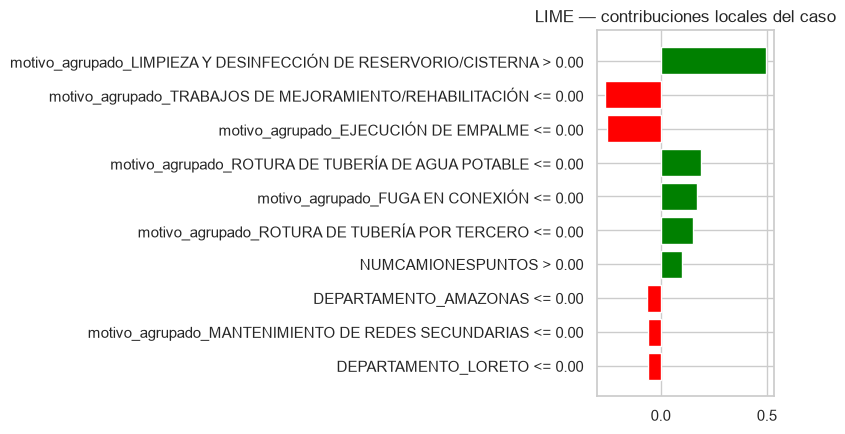

In [14]:
explicador_lime = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X.columns),
    class_names=["IMPREVISTA", "PROGRAMADA"],
    mode="classification",
    random_state=RANDOM_STATE,
)
explicacion = explicador_lime.explain_instance(
    X_test.loc[idx_caso].values,
    lambda arr: ganador.predict_proba(pd.DataFrame(arr, columns=X.columns)),
    num_features=10,
)
fig = explicacion.as_pyplot_figure()
fig.set_size_inches(8, 4.5)
plt.title("LIME — contribuciones locales del caso")
plt.tight_layout()
plt.savefig(RUTA_RECURSOS / "lime_caso.png", dpi=150, bbox_inches="tight")
plt.show()

**Cómo responder "¿por qué el modelo predijo X para este caso?"**: el force plot
muestra qué features empujaron la predicción desde el valor base (proporción
histórica de PROGRAMADA) hacia la probabilidad final; LIME confirma localmente las
mismas contribuciones con un modelo lineal alrededor del caso. La interpretación
escrita del caso concreto va en el informe con los valores impresos arriba.

## 7. Artefactos para el dashboard (Fase 3)

In [15]:
RUTA_MODELOS = RAIZ / "dashboard" / "modelos"
RUTA_MODELOS.mkdir(parents=True, exist_ok=True)

comparativa.round(4).to_csv(RUTA_PROCESSED / "comparativa_modelos.csv")
tabla_desbalance.round(4).to_csv(RUTA_PROCESSED / "efecto_desbalance.csv")
tabla_leakage.round(4).to_csv(RUTA_PROCESSED / "ablacion_motivo.csv")

predicciones_test = pd.DataFrame({
    "y_real": y_test,
    "y_pred": pred_ganador,
    "proba_programada": proba_ganador.round(4),
})
predicciones_test.to_csv(RUTA_PROCESSED / "predicciones_test.csv", index=False)

paquete = {
    "modelo": ganador,
    "columnas": list(X.columns),
    "medianas_imputacion": medianas.to_dict(),
    "clase_positiva": "PROGRAMADA",
    "nombre_modelo": NOMBRE_GANADOR,
}
joblib.dump(paquete, RUTA_MODELOS / "clasificador_final.joblib")
print("guardado: comparativa_modelos.csv, efecto_desbalance.csv, ablacion_motivo.csv,")
print("          predicciones_test.csv, dashboard/modelos/clasificador_final.joblib")
print("          y PNGs de SHAP/LIME en dashboard/recursos/")

guardado: comparativa_modelos.csv, efecto_desbalance.csv, ablacion_motivo.csv,
          predicciones_test.csv, dashboard/modelos/clasificador_final.joblib
          y PNGs de SHAP/LIME en dashboard/recursos/


## Conclusiones (material para el informe)

- 6 algoritmos comparados: gana **Random Forest** (F1_PROG 0.912, ROC-AUC 0.986)
  sobre XGBoost (0.890), MLP (0.885), KNN (0.875) y logística (0.842); Naive Bayes
  colapsa (0.386) por sus supuestos gaussianos sobre dummies binarias.
- Desbalance 76/24: `class_weight='balanced'` sube el recall de PROGRAMADA
  0.885 → 0.918 con F1 estable; SMOTE logra un efecto similar pero más caro
  (`efecto_desbalance.csv`).
- Leakage: sin `motivo_agrupado` el F1 cae a 0.753 pero AUC 0.923 — el motivo se
  mantiene por ser información operativamente disponible; el modelo no es una
  tabla de búsqueda (`ablacion_motivo.csv`).
- SHAP global + force plot y LIME responden el "¿por qué?" de cada predicción.
- El error más costoso es tratar una IMPREVISTA como PROGRAMADA → vigilar la
  precisión de la clase PROGRAMADA además del recall.